In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [4]:
(X_train, Y_train), (x_test,y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [5]:
print(X_train.shape)

(50000, 32, 32, 3)


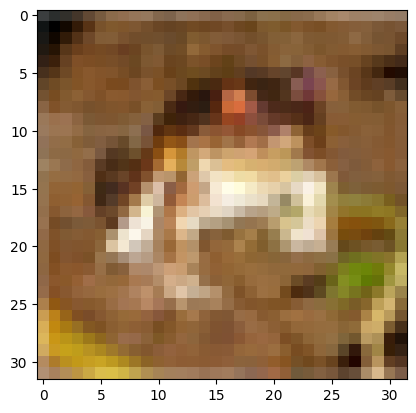

In [6]:
plt.imshow(X_train[0])
plt.show()

In [7]:
X_train = X_train /255.0
x_test = x_test /255.0

In [8]:
model = keras.Sequential([layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
layers.MaxPooling2D((2,2)),

(<MaxPooling2D name=max_pooling2d, built=True>,)

In [10]:
layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),

(<MaxPooling2D name=max_pooling2d_1, built=True>,)

In [19]:
keras.layers.Flatten(),

(<Flatten name=flatten_1, built=False>,)

In [12]:
layers.Dense(64, activation='relu'),
layers.Dense(10, activation='softmax')

<Dense name=dense_1, built=False>

In [31]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

In [34]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - accuracy: 0.3258 - loss: 1.8318 - val_accuracy: 0.5401 - val_loss: 1.2683
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.5195 - loss: 1.3380 - val_accuracy: 0.6169 - val_loss: 1.1298
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5713 - loss: 1.1925 - val_accuracy: 0.6394 - val_loss: 1.0353
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.6102 - loss: 1.0945 - val_accuracy: 0.6670 - val_loss: 0.9629
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6342 - loss: 1.0277 - val_accuracy: 0.6739 - val_loss: 0.9333
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.6636 - loss: 0.9621 - val_accuracy: 0.6749 - val_loss: 0.9314
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.6785 - loss: 0.9125 - val_accuracy: 0.6732 - val_loss: 0.9338
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6846 -

In [29]:
model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',
    input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.1201 - loss: 2.3012


[2.3003625869750977, 0.1185000017285347]

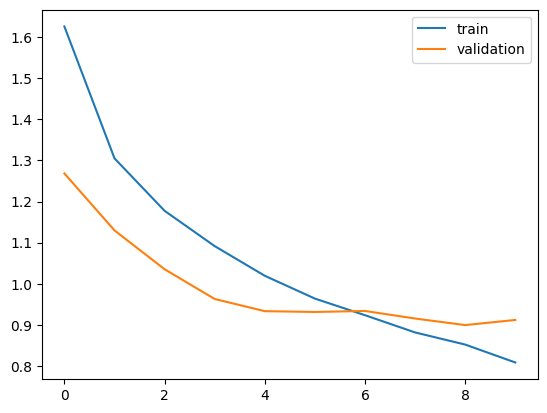

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.show()

In [27]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [36]:
prediction =model.predict(x_test[0:1])
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
[[0.00530193 0.01522786 0.03627985 0.65126884 0.00376641 0.08820622
  0.10671555 0.00185329 0.06848271 0.02289736]]


In [38]:
import numpy as np
prediction_class = np.argmax(prediction)
print(prediction_class)

3


In [40]:
print("actual:",y_test[0])
print("predicted:",prediction_class)

actual: [3]
predicted: 3


In [41]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6950 - loss: 0.8954
test accuracy: 0.6919999718666077


In [42]:
import numpy as np
import matplotlib.pyplot as plt
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


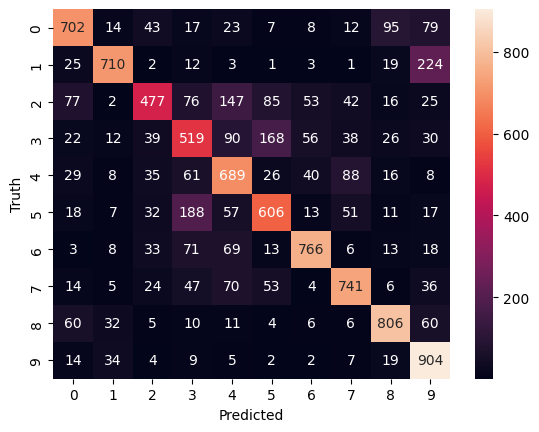

In [43]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_classes)
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt ='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [44]:
model.save("cnn_model.h5")

In [46]:
from tensorflow.keras.preprocessing import image
img = image.load_img("test.jpg",
target_size=(32,32))
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)
print(np.argmax(prediction))


FileNotFoundError: [Errno 2] No such file or directory: 'test.jpg'